    Clasificación de Especies con el Dataset Iris con diferentes modelos de Machine Learning
    Autor: Nelson Leonardo Páez Arias

# Importación y carga de datos

En este segmento se prepara el entorno de trabajo importando las bibliotecas necesarias para manipular y visualizar los datos, y luego carga el conjunto de datos Iris a trabajar. También realiza una revisión inicial para verificar las dimensiones del dataframe, los tipos de datos y la ausencia de valores nulos, confirmando que la información está en buen estado antes de continuar con el procesamiento.

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Carga del dataset
ruta = '/content/1 dataset_flor_iris.csv'

try:
    dataset = pd.read_csv(ruta)
    print("✅ Dataset cargado correctamente.\n")
except FileNotFoundError:
    # Bloque de seguridad por si falla la ruta local en Colab saber cual es el error
    print("⚠️No se encontró el archivo. Cargando Iris desde scikit-learn como respaldo...")
    from sklearn.datasets import load_iris
    iris_temp = load_iris()
    dataset = pd.DataFrame(data=np.c_[iris_temp['data'], iris_temp['target']],
                           columns=iris_temp['feature_names'] + ['Target'])
    # Mapeo numérico a texto para que sea idéntico a un CSV normal
    mapa_especies = {0: 'Setosa', 1: 'Versicolor', 2: 'Virginica'}
    dataset['Target'] = dataset['Target'].map(mapa_especies)

# Inspección básica
print("--- Primeras 5 filas (head) ---")
print(dataset.head(), "\n")

print("--- Últimas 5 filas (tail) ---")
print(dataset.tail(), "\n")

print(f"--- Dimensiones del dataset (shape) ---")
print(f"Filas: {dataset.shape[0]}, Columnas: {dataset.shape[1]}\n")

print("--- Información de tipos de datos y valores nulos ---")
print(dataset.info())
print("\nValores nulos por columna:\n", dataset.isnull().sum())

✅ Dataset cargado correctamente.

--- Primeras 5 filas (head) ---
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa 

--- Últimas 5 filas (tail) ---
      Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm  \
145  146            6.7           3.0            5.2           2.3   
146  147            6.3           2.5            5.0           1.9   
147  148            6.5           3.0            5.2           2.0   
148  149            6.2           3.4            5.4           2.3   
149  150            5.9           3.0            5.1           1.8   

            Specie

# Análisis Exploratorio de los datos (EDA)

Posteriormente se realiza el análisis exploratorio de datos mediante un gráfico de dispersión por pares (pairplot), excluyendo variables que no aportan información predictiva, como el identificador único. Esta visualización permite identificar patrones en los datos, observar cómo se distribuyen las variables y evaluar el grado de separación entre las especies, lo que indica cuáles son fáciles de distinguir y cuáles presentan características más parecidas entre sí.

<Figure size 1000x800 with 0 Axes>

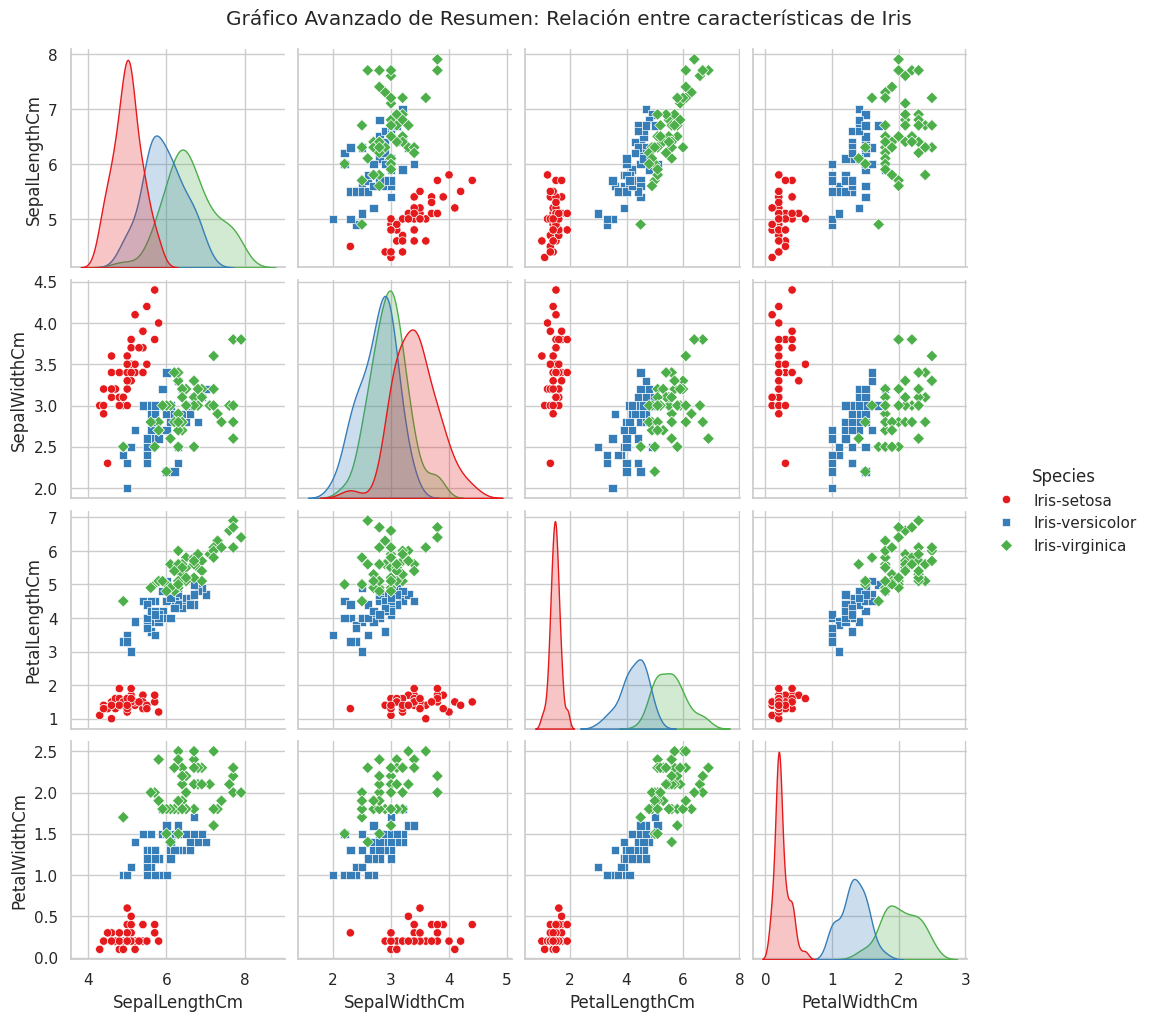

In [48]:
sns.set(style="whitegrid")

plt.figure(figsize=(10, 8))
# se usa drop('Id', axis=1) para que no grafique la columna de IDs
# Y se usa hue="Species" que es el nombre correcto en el archivo
sns.pairplot(dataset.drop('Id', axis=1), hue="Species", palette="Set1", markers=["o", "s", "D"])
plt.suptitle("Gráfico Avanzado de Resumen: Relación entre características de Iris", y=1.02)
plt.show()

# Preparación de datos y creación del modelo de Regresión Logística

En este segmento se preparan los datos, un paso necesario para que el algoritmo creado para los diferentes modelos funcione correctamente. Primero se separa la variable que se quiere predecir de las características que se usarán para predecirla, y se divide el conjunto de datos en un 80% para entrenamiento y un 20% para prueba. Después se estandarizan las variables predictoras para que tengan media cero y varianza uno. Este paso es importante para la regresión logística porque permite que el optimizador encuentre el mínimo de la función de costo de forma más estable, sin que las diferencias de escala entre las medidas de la flor afecten el resultado.

In [49]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separar variables predictoras (X) de la variable objetivo (y)
# Eliminar 'Id' porque no es predictiva, y 'Species' porque es la respuesta a predecir
X = dataset.drop(['Id', 'Species'], axis=1)
y = dataset['Species']

# División 80% entrenamiento, 20% prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Estandarización de las variables numéricas
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Datos separados y estandarizados correctamente.")
print(f"Tamaño de Entrenamiento: {X_train_scaled.shape[0]} muestras.")
print(f"Tamaño de Prueba: {X_test_scaled.shape[0]} muestras.")

Datos separados y estandarizados correctamente.
Tamaño de Entrenamiento: 120 muestras.
Tamaño de Prueba: 30 muestras.


Después de tener listos los datos, se crea y entrena el modelo de Regresión Logística. Se utiliza el optimizador L-BFGS, adecuado para resolver problemas de clasificación con más de dos clases mediante un enfoque multinomial. Durante el entrenamiento, el modelo ajusta los pesos y sesgos que definen las fronteras de decisión necesarias para clasificar las especies de Iris a partir de sus probabilidades.

In [50]:
# BLOQUE 4: ENTRENAMIENTO DEL MODELO
from sklearn.linear_model import LogisticRegression

# Inicializar y entrenar el modelo
modelo_logistico = LogisticRegression(solver='lbfgs', max_iter=200)
modelo_logistico.fit(X_train_scaled, y_train)

print(" ✅ Modelo de Regresión Logística entrenado exitosamente.")

 ✅ Modelo de Regresión Logística entrenado exitosamente.


# Evaluación del desempeño y conclusiones del modelo de Regresión Logística

Finalmente, este segmento de código mide el desempeño del modelo entrenado comparándolo con el conjunto de prueba, que contiene datos que el algoritmo no usó durante el entrenamiento. Se calculan la exactitud global y, con un promedio macro, la precisión, la sensibilidad (recall) y el F1-Score, de modo que el rendimiento se evalúe de forma equitativa en las tres especies. Además, se genera una Matriz de Confusión que compara las predicciones con los valores reales, lo que permite identificar en qué casos el modelo se equivoca al clasificar.

--- MÉTRICAS DE EVALUACIÓN ---
Accuracy (Exactitud): 0.933333
Precision (Precisión): 0.933333
Recall (Sensibilidad): 0.933333
F1-Score: 0.9333

--- REPORTE DETALLADO POR CLASE ---
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.90      0.90      0.90        10
 Iris-virginica       0.90      0.90      0.90        10

       accuracy                           0.93        30
      macro avg       0.93      0.93      0.93        30
   weighted avg       0.93      0.93      0.93        30



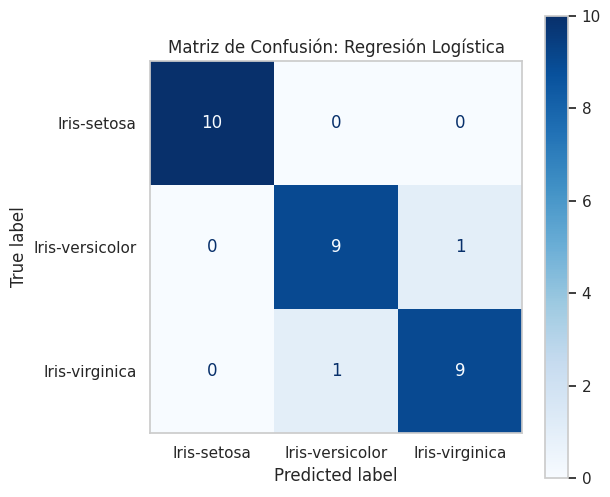

In [51]:
# BLOQUE 5: EVALUACIÓN DEL DESEMPEÑO
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Realizar predicciones con los datos de prueba
y_pred = modelo_logistico.predict(X_test_scaled)

# Cálculo de métricas de evaluación
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')

print("--- MÉTRICAS DE EVALUACIÓN ---")
print(f"Accuracy (Exactitud): {accuracy:.6f}")
print(f"Precision (Precisión): {precision:.6f}")
print(f"Recall (Sensibilidad): {recall:.6f}")
print(f"F1-Score: {f1:.4f}\n")

print("--- REPORTE DETALLADO POR CLASE ---")
print(classification_report(y_test, y_pred))

# Generar y mostrar la Matriz de Confusión
cm = confusion_matrix(y_test, y_pred, labels=modelo_logistico.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=modelo_logistico.classes_)

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title("Matriz de Confusión: Regresión Logística")
plt.grid(False)
plt.show()

    Conclusiones

1. Las métricas de evaluación confirman que la división de los datos funcionó correctamente. El modelo se entrenó con 120 muestras para ajustar sus parámetros y se reservaron 30 muestras para la evaluación. En la columna support del reporte de clasificación se observa que esas 30 muestras están divididas de forma equitativa (10 por cada especie). Este balance es importante porque garantiza que el Accuracy global del 93.33% sea una medida de rendimiento real y no esté ocultando un sesgo hacia alguna clase.

2. Al revisar el gráfico Pairplot se observa que los puntos correspondientes a Iris-setosa forman un grupo completamente separado del resto en casi todas las combinaciones de variables. La regresión logística aprovechó esta característica y logró trazar una frontera de decisión sin ninguna interferencia. Esto se refleja en el reporte de clasificación, donde Iris-setosa obtiene 1.00 en Precision, Recall y F1-Score. La matriz de confusión lo confirma: 10 aciertos sobre 10 intentos, sin falsos positivos ni falsos negativos.

3. El modelo de Regresión Logística tuvo un buen desempeño. Su comportamiento coincide con lo esperado para este tipo de algoritmo: una alta precisión en espacios linealmente separables y una tasa de error mínima.

# Preparación de datos y creación del modelo Random Forest

En este segmento de codigo se preparan los datos separando las características morfológicas de la flor (X) de la especie que se quiere predecir (y). El conjunto de datos se divide en 80% para entrenamiento y 20% para evaluación, usando un muestreo estratificado que mantiene la misma proporción de especies en ambos grupos. Por último, se aplica una estandarización a las variables predictoras, aunque no es un requisito matemático para Random Forest, se mantiene por coherencia con el resto del proyecto.

In [52]:
# BLOQUE 3: PREPARACIÓN DE DATOS
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separar variables predictoras (X) de la variable objetivo (y)
# Eliminar 'Id' porque no es predictiva, y 'Species' porque es la respuesta a adivinar
X = dataset.drop(['Id', 'Species'], axis=1)
y = dataset['Species']

# División 80% entrenamiento, 20% prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Estandarización de las variables numéricas
# Nota: Aunque Random Forest no es sensible a la escala de los datos,
# mantenemos el StandardScaler por buenas prácticas y coherencia en el pipeline.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Datos separados y estandarizados correctamente.")
print(f"Tamaño de Entrenamiento: {X_train_scaled.shape[0]} muestras.")
print(f"Tamaño de Prueba: {X_test_scaled.shape[0]} muestras.")

Datos separados y estandarizados correctamente.
Tamaño de Entrenamiento: 120 muestras.
Tamaño de Prueba: 30 muestras.


Posteriormente, se crea y entrena el algoritmo Random Forest, que combina un conjunto de 100 árboles de decisión distintos (n_estimators=100). En lugar de depender de una sola regla de clasificación, el modelo permite que estos 100 árboles analicen los datos y voten por la especie a la que pertenece cada flor. Este enfoque reduce el riesgo de sobreajuste y mejora la precisión del modelo.

In [53]:
from sklearn.ensemble import RandomForestClassifier

# Inicializar y entrenar el modelo
modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
modelo_rf.fit(X_train_scaled, y_train)

print("✅Modelo Random Forest entrenado exitosamente.")

✅Modelo Random Forest entrenado exitosamente.


# Evaluación del desempeño y conclusiones del modelo Random Forest

Finalmente, se mide el desempeño del modelo entrenado comparándolo con el conjunto de prueba, que contiene datos que el algoritmo no usó durante el entrenamiento. Se calculan la exactitud global y, con un promedio macro, la precisión, la sensibilidad (recall) y el F1-Score, de modo que el rendimiento se evalúe de forma equitativa en las tres especies. Además, se genera una Matriz de Confusión que compara las predicciones con los valores reales, lo que permite identificar en qué casos el modelo se equivoca al clasificar.

--- MÉTRICAS DE EVALUACIÓN ---
Accuracy (Exactitud): 0.9000
Precision (Precisión): 0.9024
Recall (Sensibilidad): 0.9000
F1-Score: 0.8997

--- REPORTE DETALLADO POR CLASE ---
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.82      0.90      0.86        10
 Iris-virginica       0.89      0.80      0.84        10

       accuracy                           0.90        30
      macro avg       0.90      0.90      0.90        30
   weighted avg       0.90      0.90      0.90        30



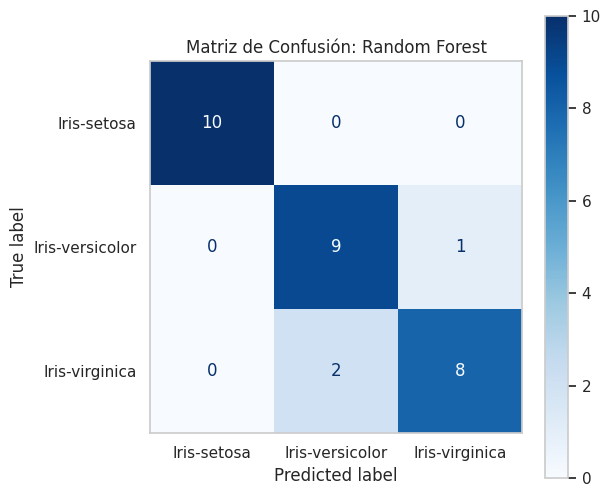

In [54]:
#BLOQUE 5: EVALUACIÓN DEL DESEMPEÑO
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Realizar predicciones con los datos de prueba
y_pred = modelo_rf.predict(X_test_scaled)

# Cálculo de métricas individuales
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')

print("--- MÉTRICAS DE EVALUACIÓN ---")
print(f"Accuracy (Exactitud): {accuracy:.4f}")
print(f"Precision (Precisión): {precision:.4f}")
print(f"Recall (Sensibilidad): {recall:.4f}")
print(f"F1-Score: {f1:.4f}\n")

print("--- REPORTE DETALLADO POR CLASE ---")
print(classification_report(y_test, y_pred))

# Generar y mostrar la Matriz de Confusión
cm = confusion_matrix(y_test, y_pred, labels=modelo_rf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=modelo_rf.classes_)

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title("Matriz de Confusión: Random Forest")
plt.grid(False) # Quitar cuadrícula de fondo para la matriz
plt.show()

    Conclusiones

1. El algoritmo de Random Forest alcanzó una exactitud (Accuracy) del 90.00% sobre el conjunto de prueba, lo que indica una buena capacidad predictiva. Al revisar los resultados por clase, se observa que el algoritmo logró una clasificación perfecta para la especie Setosa, con un puntaje de 1.00 en precisión, sensibilidad y F1-Score. La matriz de confusión confirma este resultado, ya que las 10 muestras de esta categoría fueron clasificadas correctamente, sin falsos positivos ni falsos negativos.

2. El margen de error del 10% en la evaluación global se concentra en la frontera entre las especies Versicolor y Virginica. La matriz de confusión muestra que el modelo clasificó correctamente 9 de las 10 muestras Versicolor, con un solo error al etiquetar una muestra como Virginica. El mayor desafío se presentó con la clase Virginica, donde el modelo identificó correctamente 8 observaciones, pero clasificó erróneamente 2 de ellas como Versicolor. Esta distribución de errores muestra la dificultad del modelo para separar con precisión los datos en la zona donde las características físicas de ambas flores son más parecidas.

# Preparación de datos y creación del modelo de Arboles de desición

Siguiendo el mismo proceso de preparación usado en los bloques anteriores, en este paso se separan las variables predictoras de la etiqueta objetivo y se realiza una división estratificada de 80/20. También se mantiene la estandarización numérica para conservar la coherencia en todo el proyecto, aunque el Árbol de Decisión no es sensible a las diferencias de escala entre variables.

In [55]:
#  BLOQUE 3: PREPARACIÓN DE DATOS
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separar variables predictoras (X) de la variable objetivo (y)
# Se elimina 'Id' porque no es predictiva, y 'Species' porque es la respuesta a predecir
X = dataset.drop(['Id', 'Species'], axis=1)
y = dataset['Species']

# División 80% entrenamiento, 20% prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Estandarización de las variables numéricas
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Datos separados y estandarizados correctamente.")
print(f"Tamaño de Entrenamiento: {X_train_scaled.shape[0]} muestras.")
print(f"Tamaño de Prueba: {X_test_scaled.shape[0]} muestras.")

Datos separados y estandarizados correctamente.
Tamaño de Entrenamiento: 120 muestras.
Tamaño de Prueba: 30 muestras.


En este segmento se crea y entrena un único Árbol de Decisión (DecisionTreeClassifier). Este algoritmo usa la ganancia de información para realizar divisiones sucesivas en los datos. Al configurar la profundidad máxima (max_depth=3), se limita intencionalmente el crecimiento del árbol para mejorar su capacidad de generalización, evitando que memorice detalles irrelevantes y sufra de sobreajuste.

In [56]:
from sklearn.tree import DecisionTreeClassifier

# Inicializar y entrenar el modelo de Árbol de Decisión puro
# max_depth=3 limita el crecimiento del árbol para evitar sobreajuste
modelo_arbol = DecisionTreeClassifier(max_depth=3, random_state=42)
modelo_arbol.fit(X_train_scaled, y_train)

print("✅ Modelo de Árbol de Decisión entrenado exitosamente.\n")

✅ Modelo de Árbol de Decisión entrenado exitosamente.



# Evaluación del desempeño y conclusiones del modelo de Arboles de desición

Finalmente, este bloque mide el rendimiento del Árbol de Decisión usando las mismas métricas de evaluación de los modelos anteriores. Se calculan estas métricas con un promedio que pondera de forma equitativa el desempeño en las tres clases, y se genera una Matriz de Confusión que muestra cómo las divisiones del árbol resolvieron o no la zona de ambigüedad entre especies.

--- MÉTRICAS DE EVALUACIÓN (ÁRBOL DE DECISIÓN) ---
Accuracy (Exactitud): 0.9667
Precision (Precisión): 0.9697
Recall (Sensibilidad): 0.9667
F1-Score: 0.9666

--- REPORTE DETALLADO POR CLASE ---
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.90      0.95        10
 Iris-virginica       0.91      1.00      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30



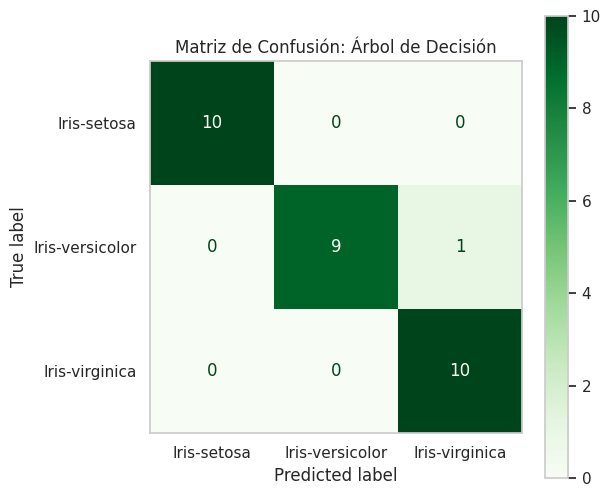

In [57]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Realizar predicciones con los datos de prueba
y_pred_arbol = modelo_arbol.predict(X_test_scaled)

# Cálculo de métricas individuales
accuracy = accuracy_score(y_test, y_pred_arbol)
precision = precision_score(y_test, y_pred_arbol, average='macro')
recall = recall_score(y_test, y_pred_arbol, average='macro')
f1 = f1_score(y_test, y_pred_arbol, average='macro')

print("--- MÉTRICAS DE EVALUACIÓN (ÁRBOL DE DECISIÓN) ---")
print(f"Accuracy (Exactitud): {accuracy:.4f}")
print(f"Precision (Precisión): {precision:.4f}")
print(f"Recall (Sensibilidad): {recall:.4f}")
print(f"F1-Score: {f1:.4f}\n")

print("--- REPORTE DETALLADO POR CLASE ---")
print(classification_report(y_test, y_pred_arbol))

# Generar y mostrar la Matriz de Confusión
cm = confusion_matrix(y_test, y_pred_arbol, labels=modelo_arbol.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=modelo_arbol.classes_)

# Usamos un mapa de colores 'Greens' para diferenciar visualmente este modelo
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap='Greens', ax=ax, values_format='d')
plt.title("Matriz de Confusión: Árbol de Decisión")
plt.grid(False)
plt.show()

    Conclusión

El modelo de Árbol de Decisión alcanzó una exactitud del 96.67%, lo que lo convierte en el algoritmo con mejor desempeño sobre el conjunto de prueba. Al igual que los modelos anteriores, logró una precisión perfecta para la especie Setosa, identificando las 10 observaciones sin ningún error. Su buen resultado se nota especialmente en la zona donde Versicolor y Virginica se parecen más: clasificó correctamente el 100% de las muestras reales de Virginica y cometió un único error al etiquetar una flor Versicolor como Virginica. Esto confirma que limitar la profundidad del árbol (max_depth=3) funcionó como un mecanismo de regularización, evitando que el modelo memorizara ruido estadístico.

# Comparación de modelos y conclusiones finales

--- TABLA COMPARATIVA DE RENDIMIENTO ---


,Modelo,Accuracy,Precision (Macro),Recall (Macro),F1-Score (Macro)
0,Regresión Logística,0.9333,0.9333,0.9333,0.9333
1,Random Forest,0.9000,0.9024,0.9000,0.8997
2,Árbol de Decisión,0.9667,0.9697,0.9667,0.9666


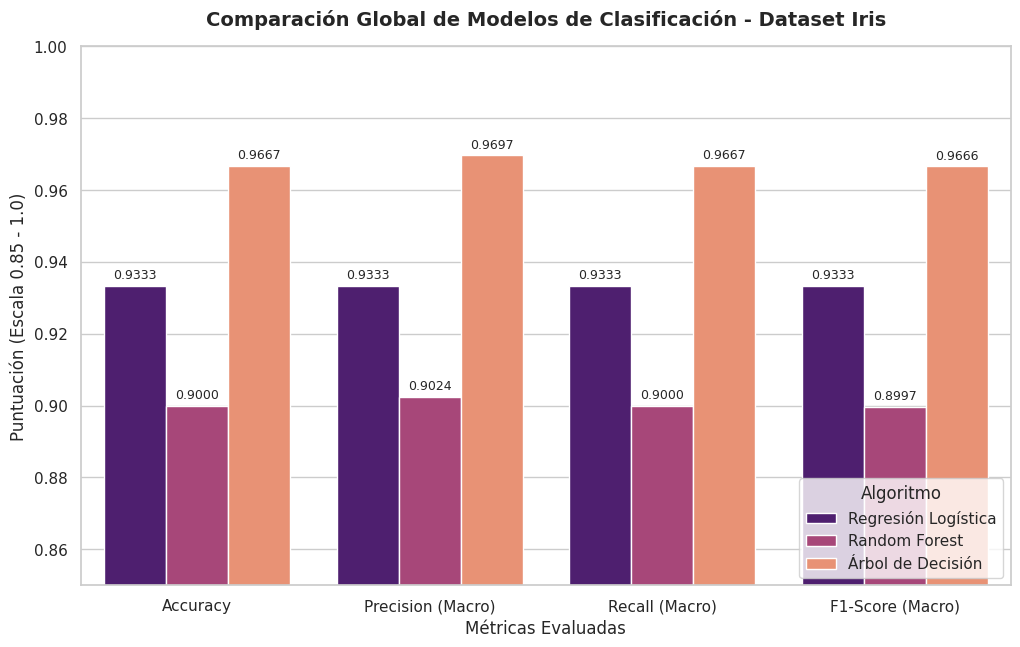

In [58]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Creación de un DataFrame con las métricas consolidadas de tus resultados
datos_comparativos = {
    'Modelo': ['Regresión Logística', 'Random Forest', 'Árbol de Decisión'],
    'Accuracy': [0.9333, 0.9000, 0.9667],
    'Precision (Macro)': [0.9333, 0.9024, 0.9697],
    'Recall (Macro)': [0.9333, 0.9000, 0.9667],
    'F1-Score (Macro)': [0.9333, 0.8997, 0.9666]
}

df_comparacion = pd.DataFrame(datos_comparativos)

# 2. Mostrar la tabla comparativa en la consola
print("--- TABLA COMPARATIVA DE RENDIMIENTO ---")
display(df_comparacion)

# 3. Transformar los datos a formato largo para facilitar la gráfica en Seaborn
df_melted = df_comparacion.melt(id_vars='Modelo', var_name='Métrica', value_name='Puntuación')

# 4. Generación del gráfico de barras agrupado
sns.set(style="whitegrid")
plt.figure(figsize=(12, 7))

# Se usa una paleta de colores para distinguir visualmente cada modelo
grafico = sns.barplot(x='Métrica', y='Puntuación', hue='Modelo', data=df_melted, palette='magma')
plt.ylim(0.85, 1.0)
plt.title('Comparación Global de Modelos de Clasificación - Dataset Iris', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Puntuación (Escala 0.85 - 1.0)', fontsize=12)
plt.xlabel('Métricas Evaluadas', fontsize=12)
plt.legend(title='Algoritmo', loc='lower right')

# Añadir las etiquetas de valores sobre cada barra para mayor claridad
for container in grafico.containers:
    grafico.bar_label(container, fmt='%.4f', padding=3, fontsize=9)

plt.show()

El análisis comparativo de los tres algoritmos muestra que el Árbol de Decisión es el modelo más adecuado para este problema de clasificación, con la máxima exactitud: 96.67%. Al comparar las métricas, se observa que la Regresión Logística tuvo un buen desempeño modelando las fronteras lineales entre clases, alcanzando un 93.33% de precisión, pero fue superada por la capacidad del árbol para dividir con mayor precisión la zona donde se mezclan Versicolor y Virginica. Por su parte, el modelo de Random Forest obtuvo el rendimiento más bajo, con un 90.00%. Esto refleja que, en conjuntos de datos pequeños y de baja dimensionalidad como el dataset Iris, combinar muchos árboles puede introducir ruido estadístico y reducir la capacidad de generalización del modelo.